## Import All Modules

In [ ]:
import os
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt
import shutil

## Verify Dataset Paths

### Subtask:
Confirm the existence of the specified dataset directories (`dataset/final/0`, `dataset/final/1`, `dataset/final/2`) and display a sample of the images to ensure correct paths and content.


**Reasoning**:
The first step is to import necessary libraries, define the directory paths, and verify their existence. This ensures the environment is set up correctly before proceeding with image sampling and display.



In [61]:
directories = [
    'Dataset/Final/0',
    'Dataset/Final/1',
    'Dataset/Final/2'
]

print("Verifying dataset directory existence:")
for directory in directories:
    if os.path.exists(directory):
        print(f"Directory '{directory}' exists.")
    else:
        print(f"Directory '{directory}' does not exist. Please check the path.")


Verifying dataset directory existence:
Directory 'Dataset/Final/0' exists.
Directory 'Dataset/Final/1' exists.
Directory 'Dataset/Final/2' exists.


**Reasoning**:
Now that the directories are verified, the next step is to sample and display images from each directory to confirm their content as per the subtask instructions.



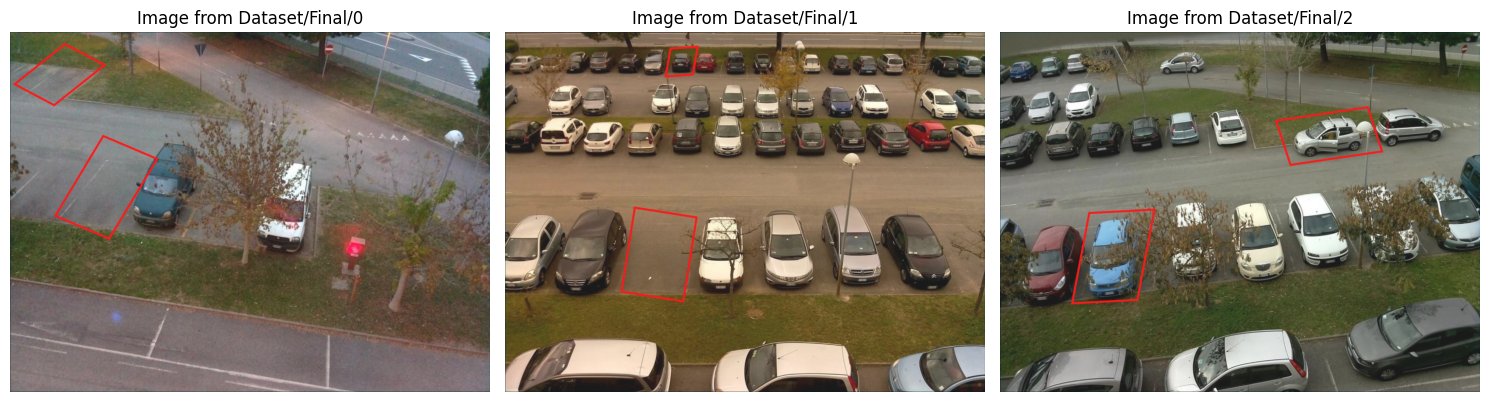

In [62]:
plt.figure(figsize=(15, 5))
image_count = 0

for i, directory in enumerate(directories):
    image_paths = glob.glob(os.path.join(directory, '*.jpg')) + glob.glob(os.path.join(directory, '*.png'))

    if not image_paths:
        print(f"No image files found in '{directory}'.")
        continue

    # Select one random image per directory for display
    sample_image_path = random.choice(image_paths)

    try:
        img = Image.open(sample_image_path)
        image_count += 1
        plt.subplot(1, len(directories), image_count)
        plt.imshow(img)
        plt.title(f'Image from {directory}')
        plt.axis('off')
    except Exception as e:
        print(f"Could not open image {sample_image_path}: {e}")

plt.tight_layout()
plt.show()


## Split, Resize, and Organize Dataset for YOLOv8 Classification

### Subtask:
Create training and validation splits from the raw data. Resize all images to a uniform size to handle slight variations in dimensions. Organize the resized images into the directory structure expected by YOLOv8 for classification (e.g., `dataset/train/0`, `dataset/val/1`, etc.).


In [63]:
# 1. Define target image size and train-validation split ratio
TARGET_IMAGE_SIZE = (224, 224)  # YOLOv8 typically uses square images
TRAIN_SPLIT_RATIO = 0.8

# Base directories for the original dataset (already defined in previous cells)
# directories = [
#     'dataset/final/0',
#     'dataset/final/1',
#     'dataset/final/2'
# ]

# Output directories
BASE_OUTPUT_DIR = 'processed_dataset'
TRAIN_DIR = os.path.join(BASE_OUTPUT_DIR, 'train')
VAL_DIR = os.path.join(BASE_OUTPUT_DIR, 'val')

# 2. Create the base output directories for the organized dataset
print(f"Creating output directories: {TRAIN_DIR} and {VAL_DIR}")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

print("Output directories created successfully.")

Creating output directories: processed_dataset\train and processed_dataset\val
Output directories created successfully.


Now that the base directories are set up, we will iterate through each class directory, split the images into training and validation sets, resize them to the target size, and then save them to the appropriate new directories, as specified in the instructions.



In [64]:
# Initialize dictionaries to store counts for verification
train_counts = {}
val_counts = {}

print("Starting image splitting, resizing, and organization...")

for original_dir in directories:
    class_label = os.path.basename(original_dir) # e.g., '0', '1', '2'

    # Get all image paths for the current class
    all_image_paths = glob.glob(os.path.join(original_dir, '*.jpg')) + glob.glob(os.path.join(original_dir, '*.png'))
    random.shuffle(all_image_paths)

    if not all_image_paths:
        print(f"No image files found in '{original_dir}'. Skipping.")
        continue

    # Split into training and validation sets
    split_index = int(len(all_image_paths) * TRAIN_SPLIT_RATIO)
    train_images = all_image_paths[:split_index]
    val_images = all_image_paths[split_index:]

    # Create class-specific directories in train and val
    os.makedirs(os.path.join(TRAIN_DIR, class_label), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, class_label), exist_ok=True)

    # Process training images
    train_count = 0
    for img_path in train_images:
        try:
            img = Image.open(img_path).convert('RGB')
            img_resized = img.resize(TARGET_IMAGE_SIZE, Image.LANCZOS)

            dest_path = os.path.join(TRAIN_DIR, class_label, os.path.basename(img_path))
            img_resized.save(dest_path)
            train_count += 1
        except Exception as e:
            print(f"Error processing training image {img_path}: {e}")
    train_counts[class_label] = train_count

    # Process validation images
    val_count = 0
    for img_path in val_images:
        try:
            img = Image.open(img_path).convert('RGB')
            img_resized = img.resize(TARGET_IMAGE_SIZE, Image.LANCZOS)

            dest_path = os.path.join(VAL_DIR, class_label, os.path.basename(img_path))
            img_resized.save(dest_path)
            val_count += 1
        except Exception as e:
            print(f"Error processing validation image {img_path}: {e}")
    val_counts[class_label] = val_count

print("Image processing complete.")

# Print summary
print("\nSummary of processed images:")
print("Train Set:")
for cls, count in train_counts.items():
    print(f"  Class {cls}: {count} images")
print("Val Set:")
for cls, count in val_counts.items():
    print(f"  Class {cls}: {count} images")


Starting image splitting, resizing, and organization...
Image processing complete.

Summary of processed images:
Train Set:
  Class 0: 84 images
  Class 1: 108 images
  Class 2: 92 images
Val Set:
  Class 0: 22 images
  Class 1: 27 images
  Class 2: 24 images


# TASK - Data Preprocessing

Crop red regions from the images and split into:  
- 0 for empty slots.
- 1 for ambiguous, i.e slot can be empty or full.
- 2 for full slot, i.e vehicle is parked.

Creating base output directory for cropped images: cropped_red_regions
Base output directory created successfully.

Starting detection and cropping of red bounding boxes...
Processing images in 'Dataset/Final/0' (Class 0)...
Processing images in 'Dataset/Final/1' (Class 1)...
Processing images in 'Dataset/Final/2' (Class 2)...

Finished detecting and cropping. Total red regions cropped: 713

Verifying some cropped images in 'cropped_red_regions':
  Class 0: Found 204 cropped images.


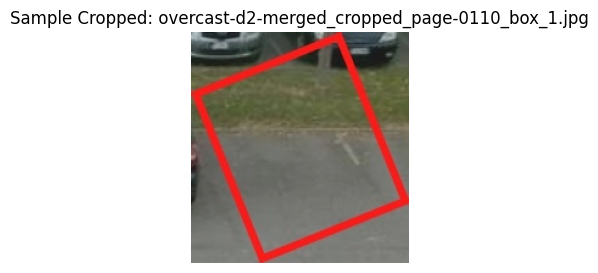

  Class 1: Found 265 cropped images.


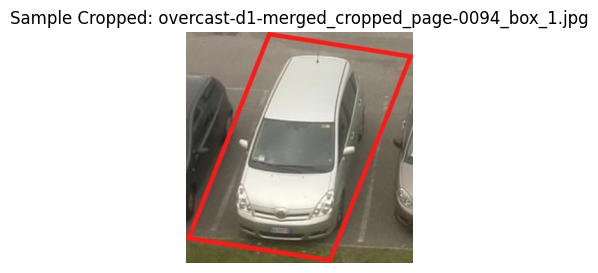

  Class 2: Found 244 cropped images.


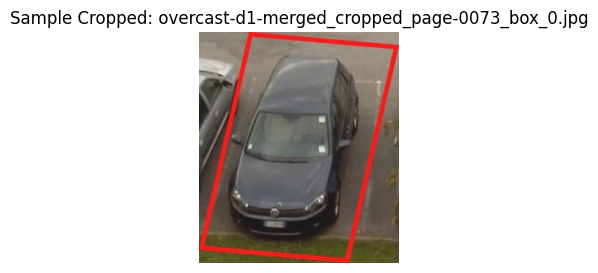

In [23]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# 1. Define the list of input directories (already defined in previous cells, but good to ensure)
# directories = [
#     'Dataset/Final/0',
#     'Dataset/Final/1',
#     'Dataset/Final/2'
# ]

# 2. Define a base output directory for the cropped images
BASE_CROPPED_OUTPUT_DIR = 'cropped_red_regions'

# 3. Create the BASE_CROPPED_OUTPUT_DIR if it does not already exist.
print(f"Creating base output directory for cropped images: {BASE_CROPPED_OUTPUT_DIR}")
os.makedirs(BASE_CROPPED_OUTPUT_DIR, exist_ok=True)
print("Base output directory created successfully.")

# 4. Implement a Python function, for example, detect_and_crop_red_boxes(image_path, output_base_dir, original_class_label)
def detect_and_crop_red_boxes(image_path, output_base_dir, original_class_label):
    """
    Detects red rectangular bounding boxes in an image, crops them, and saves the cropped regions.

    Args:
        image_path (str): Path to the input image.
        output_base_dir (str): Base directory where cropped images will be saved.
        original_class_label (str): The class label of the original image (e.g., '0', '1', '2').
    """
    # a. Load the image from image_path using cv2.imread(). Handle potential loading errors.
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, []

    # b. Convert the image from BGR to HSV color space using cv2.cvtColor().
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # c. Define two sets of lower and upper bounds for red color in HSV to account for the color wrapping around 0 in the hue channel.
    # Red color typically has hue values near 0 and 180 in HSV (0-180 range in OpenCV)
    # Adjusted lower bounds for S and V to make red detection stricter
    lower_red1 = np.array([0, 120, 120]) # Increased S and V minimum
    upper_red1 = np.array([10, 255, 255])
    # Upper red range
    lower_red2 = np.array([160, 120, 120]) # Increased S and V minimum
    upper_red2 = np.array([180, 255, 255])

    # d. Create binary masks for each red range using cv2.inRange() and combine them with cv2.add().
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = cv2.add(mask1, mask2)

    # e. Apply morphological operations (e.g., cv2.morphologyEx with cv2.MORPH_OPEN followed by cv2.MORPH_CLOSE) to clean up the mask and connect broken parts.
    kernel = np.ones((5, 5), np.uint8)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel) # Remove small noise
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel) # Connect nearby regions

    # f. Find contours in the cleaned mask using cv2.findContours().
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cropped_regions_count = 0
    # g. Iterate through each contour:
    for i, contour in enumerate(contours):
        # i. Calculate the bounding rectangle for the contour using cv2.boundingRect().
        x, y, w, h = cv2.boundingRect(contour)

        # ii. Filter out very small rectangles (potential noise) based on a minimum area or dimensions.
        min_area = 10000 # Increased minimum area
        min_dim = 100 # Increased minimum width or height

        # Calculate solidity: ratio of contour area to its convex hull area
        # A perfect rectangle has solidity close to 1. Irregular shapes have lower solidity.
        contour_area = cv2.contourArea(contour)
        convex_hull = cv2.convexHull(contour)
        convex_hull_area = cv2.contourArea(convex_hull)

        solidity_threshold = 0.85 # Adjust as needed. Rectangles should have high solidity.
        if convex_hull_area == 0: # Avoid division by zero
            continue
        solidity = float(contour_area) / convex_hull_area

        if solidity < solidity_threshold or w * h < min_area or w < min_dim or h < min_dim:
            continue

        # iii. Crop the region of interest from the original image using NumPy array slicing based on the bounding box coordinates.
        cropped_region = img[y:y+h, x:x+w]

        # iv. Construct a unique filename for the cropped image, incorporating the original_class_label,
        #     original image filename (without extension), and a box index
        original_filename_no_ext = os.path.splitext(os.path.basename(image_path))[0]
        output_subdir = os.path.join(output_base_dir, original_class_label)
        cropped_filename = f"{original_filename_no_ext}_box_{i}.jpg"
        dest_path = os.path.join(output_subdir, cropped_filename)

        # v. Create the output subdirectory for the original_class_label if it doesn't exist.
        os.makedirs(output_subdir, exist_ok=True)

        # vi. Save the cropped image to the constructed path using cv2.imwrite().
        cv2.imwrite(dest_path, cropped_region)
        cropped_regions_count += 1

    # if cropped_regions_count > 0:
    #     print(f"  Detected and saved {cropped_regions_count} red regions from {os.path.basename(image_path)}")
    # else:
    #     print(f"  No significant red regions detected in {os.path.basename(image_path)}")
    return cropped_regions_count


# 5. Iterate through each original_dir in the directories list:
print("\nStarting detection and cropping of red bounding boxes...")
total_cropped_images = 0
for original_dir in directories:
    # a. Extract the original_class_label (e.g., '0', '1', '2') from the directory name.
    original_class_label = os.path.basename(original_dir)

    # b. For each original_class_label, create a corresponding subdirectory within BASE_CROPPED_OUTPUT_DIR if it doesn't exist.
    os.makedirs(os.path.join(BASE_CROPPED_OUTPUT_DIR, original_class_label), exist_ok=True)

    # c. Use glob.glob() to find all image files (e.g., *.jpg, *.png) within the current original_dir.
    image_paths_in_dir = glob.glob(os.path.join(original_dir, '*.jpg')) + \
                         glob.glob(os.path.join(original_dir, '*.png'))

    if not image_paths_in_dir:
        print(f"No image files found in '{original_dir}'. Skipping.")
        continue

    print(f"Processing images in '{original_dir}' (Class {original_class_label})...")
    # d. For each image_path found, call the detect_and_crop_red_boxes function.
    for image_path in image_paths_in_dir:
        cropped_count = detect_and_crop_red_boxes(image_path, BASE_CROPPED_OUTPUT_DIR, original_class_label)
        total_cropped_images += cropped_count

print(f"\nFinished detecting and cropping. Total red regions cropped: {total_cropped_images}")

# Verify some of the cropped files
print(f"\nVerifying some cropped images in '{BASE_CROPPED_OUTPUT_DIR}':")
for class_label in class_names:
    class_cropped_dir = os.path.join(BASE_CROPPED_OUTPUT_DIR, class_label)
    cropped_files = glob.glob(os.path.join(class_cropped_dir, '*.jpg')) # Assuming JPG output
    print(f"  Class {class_label}: Found {len(cropped_files)} cropped images.")
    if cropped_files:
        # Display one random cropped image for verification
        sample_cropped_path = random.choice(cropped_files)
        img = cv2.imread(sample_cropped_path)
        if img is not None:
            # Convert BGR to RGB for matplotlib display
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(3,3))
            plt.imshow(img_rgb)
            plt.title(f"Sample Cropped: {os.path.basename(sample_cropped_path)}")
            plt.axis('off')
            plt.show()
        else:
            print(f"    Error loading sample cropped image: {sample_cropped_path}")

## TASK - Splitting cropped images into binary classes.

In [27]:
# 1. Define a base output directory for the binary classification dataset
BINARY_CLASSIFICATION_DATASET = 'binary_classification_dataset'

# 2. Define the subdirectories for the two classes: 'vehicle' and 'not_vehicle'
VEHICLE_DIR = os.path.join(BINARY_CLASSIFICATION_DATASET, 'vehicle')
NOT_VEHICLE_DIR = os.path.join(BINARY_CLASSIFICATION_DATASET, 'not_vehicle')

# 3. Create these class-specific output directories
print(f"Creating binary classification dataset directories: {VEHICLE_DIR} and {NOT_VEHICLE_DIR}")
os.makedirs(VEHICLE_DIR, exist_ok=True)
os.makedirs(NOT_VEHICLE_DIR, exist_ok=True)
print("Binary classification dataset directories created successfully.")

# Initialize counters for 'vehicle' and 'not_vehicle' images
vehicle_count = 0
not_vehicle_count = 0

print("\nStarting organization of cropped red regions into binary classification dataset...")

# 5. Iterate through the BASE_CROPPED_OUTPUT_DIR (cropped_red_regions)
# The 'directories' variable is available from previous steps as ['dataset/final/0', 'dataset/final/1', 'dataset/final/2']
# BASE_CROPPED_OUTPUT_DIR is 'cropped_red_regions'

for original_class_label_dir in ['0', '1', '2']: # Iterate through the original class labels
    source_class_path = os.path.join(BASE_CROPPED_OUTPUT_DIR, original_class_label_dir)

    # b. Use glob.glob() to find all cropped image files within the current original class subdirectory.
    cropped_image_files = glob.glob(os.path.join(source_class_path, '*.jpg')) # Assuming JPG output from previous step

    # c. For each cropped image path:
    for img_path in cropped_image_files:
        # i. If the original_class_label is '0', copy the image to the NOT_VEHICLE_DIR and increment the 'not_vehicle' counter.
        if original_class_label_dir == '0':
            destination_path = os.path.join(NOT_VEHICLE_DIR, os.path.basename(img_path))
            shutil.copy(img_path, destination_path)
            not_vehicle_count += 1
        # ii. If the original_class_label is '2', copy the image to the VEHICLE_DIR and increment the 'vehicle' counter.
        elif original_class_label_dir == '2':
            destination_path = os.path.join(VEHICLE_DIR, os.path.basename(img_path))
            shutil.copy(img_path, destination_path)
            vehicle_count += 1
        # iii. Images from original_class_label '1' should be skipped, as per the subtask description.
        # else: pass (do nothing for class '1')

print("Organization complete.")

# 7. Print a summary of the total number of images copied
print("\nSummary of binary classification dataset:")
print(f"Total 'vehicle' images: {vehicle_count}")
print(f"Total 'not_vehicle' images: {not_vehicle_count}")

Creating binary classification dataset directories: binary_classification_dataset\vehicle and binary_classification_dataset\not_vehicle
Binary classification dataset directories created successfully.

Starting organization of cropped red regions into binary classification dataset...
Organization complete.

Summary of binary classification dataset:
Total 'vehicle' images: 244
Total 'not_vehicle' images: 204


## After this pipeline, the data from ambiguous class, i.e 1 is moved manually into either vehicle / not-vehicle class. Then, we proceed to train our model.

# TASK - Train the YOLOv8n model for classification.

In [3]:
# 1. Define a base output directory for the binary classification dataset
BINARY_CLASSIFICATION_DATASET = 'binary_classification_dataset'

# 2. Define the subdirectories for the two classes: 'vehicle' and 'not_vehicle'
VEHICLE_DIR = os.path.join(BINARY_CLASSIFICATION_DATASET, 'vehicle')
NOT_VEHICLE_DIR = os.path.join(BINARY_CLASSIFICATION_DATASET, 'not_vehicle')

In [4]:
# Split the binary dataset into train/val (80/20)

SPLIT_BASE_DIR = "binary_cls_split"
TRAIN_SPLIT = 0.8
RANDOM_SEED = 42

train_dir = os.path.join(SPLIT_BASE_DIR, "train")
val_dir = os.path.join(SPLIT_BASE_DIR, "val")

class_dirs = {
    "vehicle": VEHICLE_DIR,
    "not_vehicle": NOT_VEHICLE_DIR,
}

random.seed(RANDOM_SEED)

print(f"Creating split dataset at: {SPLIT_BASE_DIR}")
for split_dir in [train_dir, val_dir]:
    os.makedirs(split_dir, exist_ok=True)

split_counts = {"train": {}, "val": {}}

for class_name, class_path in class_dirs.items():
    images = glob.glob(os.path.join(class_path, "*.jpg")) + glob.glob(os.path.join(class_path, "*.png"))
    images = [p for p in images if os.path.isfile(p)]
    if not images:
        print(f"No images found for class '{class_name}' in {class_path}")
        continue

    random.shuffle(images)
    split_index = int(len(images) * TRAIN_SPLIT)
    train_images = images[:split_index]
    val_images = images[split_index:]

    class_train_dir = os.path.join(train_dir, class_name)
    class_val_dir = os.path.join(val_dir, class_name)
    os.makedirs(class_train_dir, exist_ok=True)
    os.makedirs(class_val_dir, exist_ok=True)

    for src in train_images:
        shutil.copy(src, os.path.join(class_train_dir, os.path.basename(src)))
    for src in val_images:
        shutil.copy(src, os.path.join(class_val_dir, os.path.basename(src)))

    split_counts["train"][class_name] = len(train_images)
    split_counts["val"][class_name] = len(val_images)

print("\nSplit summary:")
for split_name in ["train", "val"]:
    print(f"{split_name.title()} set:")
    for class_name, count in split_counts[split_name].items():
        print(f"  {class_name}: {count} images")

Creating split dataset at: binary_cls_split

Split summary:
Train set:
  vehicle: 256 images
  not_vehicle: 241 images
Val set:
  vehicle: 65 images
  not_vehicle: 61 images


## Train YOLOv8n classifier (vehicle vs not_vehicle)

In [6]:
from ultralytics import YOLO

# Initialize a YOLOv8n classification model
model = YOLO("yolov8n-cls.pt")

# Train on the split dataset (expects train/ and val/ subfolders)
results = model.train(
    data=SPLIT_BASE_DIR,
    epochs=10,
    imgsz=224,
    batch=16,
    name="yolov8n_vehicle_cls"
)

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.9.25 torch-2.8.0+cpu CPU (12th Gen Intel Core i5-1240P)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=binary_cls_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_vehicle_cls, n

## Evaluate best model on test set

Using best model: C:\Users\ishan\Desktop\Final Year Report\Project\Model\runs\classify\yolov8n_vehicle_cls\weights\best.pt

Classification report (test set):
              precision    recall  f1-score   support

 not_vehicle       1.00      1.00      1.00        61
     vehicle       1.00      1.00      1.00        65

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



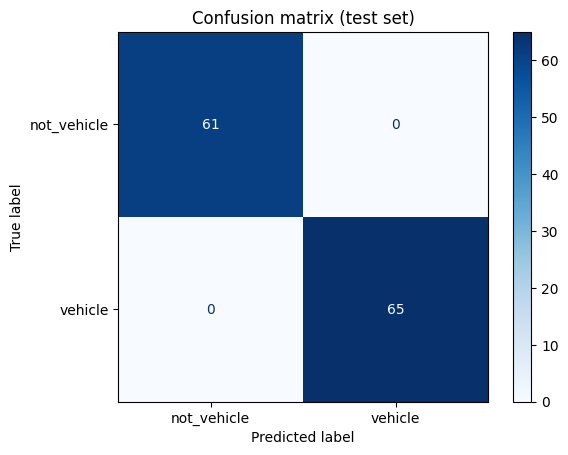

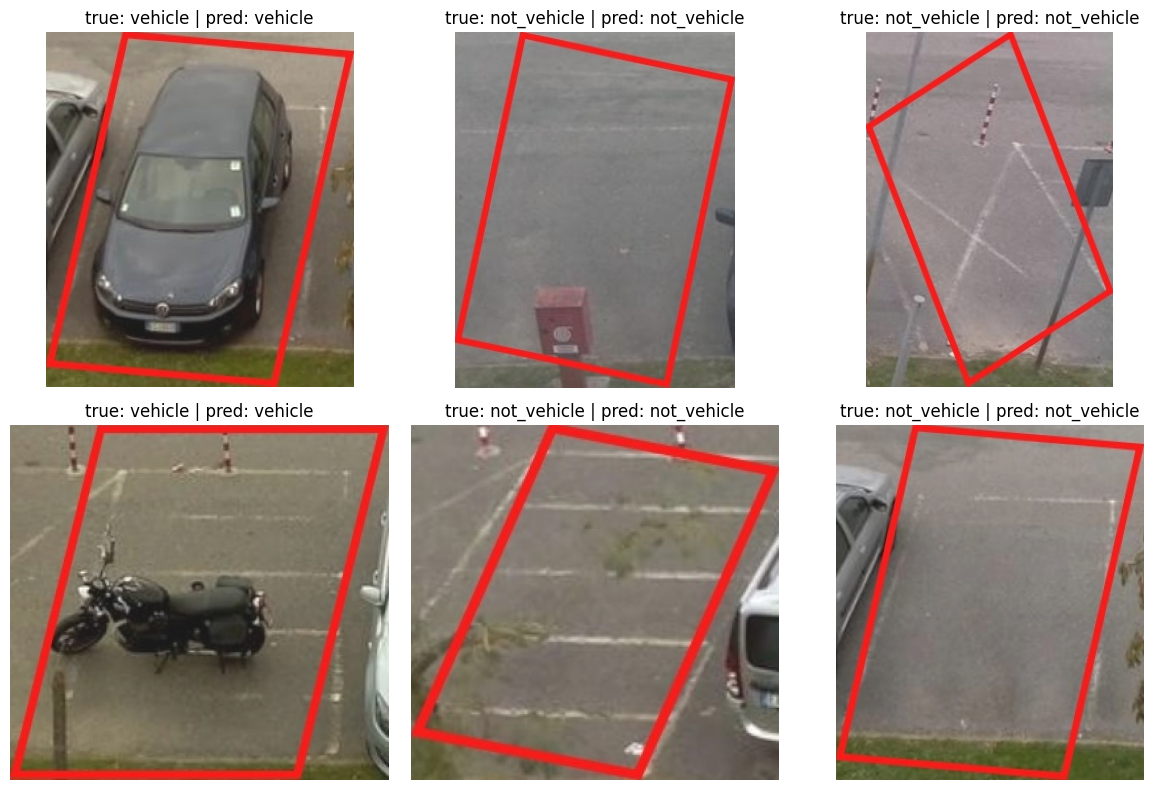

In [10]:
import os
import glob
import random
import math
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

TEST_DIR = os.path.join(SPLIT_BASE_DIR, "val")

if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(
        f"Test directory not found: {TEST_DIR}. "
        "Create a test split (e.g., binary_cls_split/val/vehicle and /not_vehicle) before running this cell."
    )

class_names = sorted(
    [d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))]
    )
if not class_names:
    raise ValueError(f"No class subfolders found in {TEST_DIR}")

class_to_idx = {name: i for i, name in enumerate(class_names)}

image_paths = []
y_true = []
for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    paths = (
        glob.glob(os.path.join(class_dir, "*.jpg"))
        + glob.glob(os.path.join(class_dir, "*.jpeg"))
        + glob.glob(os.path.join(class_dir, "*.png"))
    )
    for p in paths:
        image_paths.append(p)
        y_true.append(class_to_idx[class_name])

if not image_paths:
    raise ValueError(f"No images found under {TEST_DIR}")

best_path = None
if "results" in globals() and hasattr(results, "save_dir"):
    candidate = os.path.join(results.save_dir, "weights", "best.pt")
    if os.path.exists(candidate):
        best_path = candidate

if best_path is None:
    candidates = sorted(glob.glob("runs/classify/**/weights/best.pt", recursive=True))
    if candidates:
        best_path = candidates[-1]

if best_path is None or not os.path.exists(best_path):
    raise FileNotFoundError("Could not locate best.pt. Train the model first or set best_path manually.")

print(f"Using best model: {best_path}")
best_model = YOLO(best_path)

pred_results = best_model.predict(source=image_paths, imgsz=224, verbose=False)
y_pred = [int(r.probs.top1) for r in pred_results]

print("\nClassification report (test set):")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test set)")
plt.show()

# Show a few predictions from the test set
random.seed(42)
num_show = 6
sample_indices = random.sample(range(len(image_paths)), k=min(num_show, len(image_paths)))

cols = 3
rows = math.ceil(len(sample_indices) / cols)
plt.figure(figsize=(12, 4 * rows))
for i, idx in enumerate(sample_indices, start=1):
    img = Image.open(image_paths[idx]).convert("RGB")
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f"true: {true_label} | pred: {pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()